# İletişim Becerileri Ölçeği (İBDÖ) Analizi

**Ölçek:** Korkut Owen & Bugay (2014) — 25 madde, 4 alt boyut, 5'li Likert  
**Desen:** Tek grup, ön test – son test  
**Analizler:** Güvenirlik (Cronbach α) → Normallik (Shapiro-Wilk) → Paired t-test + Cohen's d

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Script'ten fonksiyon ve sabitleri import et
from iletisim_analiz import (
    analiz_calistir,
    FAKTÖR_ETIKET,
    FAKTÖRLER,
)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.3f}'.format)

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

RENK_ON  = '#5B9BD5'
RENK_SON = '#ED7D31'

print('Kütüphaneler yüklendi.')

Kütüphaneler yüklendi.


## 1. Veri Yükleme ve Eşleştirme

In [2]:
s = analiz_calistir()

print('─' * 40)
print(f"Ön test katılımcı sayısı  : {s['n_ontest']}")
print(f"Son test katılımcı sayısı : {s['n_sontest']}")
print(f"Eşleşen (analiz) N        : {s['n_eslesen']}")
print('─' * 40)

on  = s['on_eslesen']
son = s['son_eslesen']

────────────────────────────────────────
Ön test katılımcı sayısı  : 49
Son test katılımcı sayısı : 52
Eşleşen (analiz) N        : 44
────────────────────────────────────────


## 2. Güvenirlik Analizi (Cronbach α)

In [3]:
guv = s['guvenirlik']
display(guv.style
    .set_caption('Tablo: Cronbach Alpha Güvenirlik Katsayıları')
    .format({'Cronbach α': '{:.3f}'})
    .hide(axis='index')
)

Alt Boyut,Madde Sayısı,Cronbach α
İletişim İlkeleri ve Temel Beceriler,10,0.680
Kendini İfade Etme,4,0.716
Etkin Dinleme ve Sözel Olmayan İletişim,6,0.662
İletişim Kurmaya İsteklilik,5,0.544
İBDÖ Toplam,25,0.857


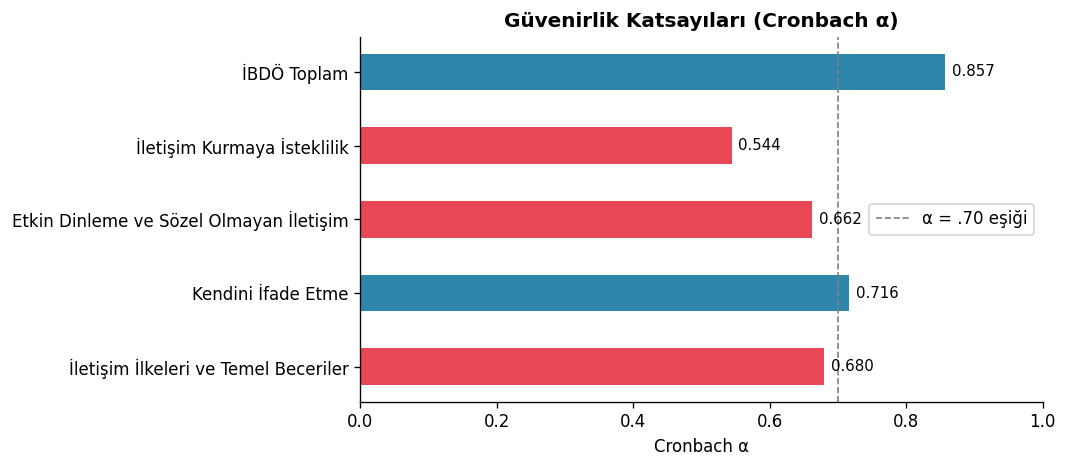

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

etiketler = guv['Alt Boyut'].tolist()
alfalar   = guv['Cronbach α'].tolist()
renkler   = ['#2E86AB' if a >= 0.70 else '#E84855' for a in alfalar]

bars = ax.barh(etiketler, alfalar, color=renkler, height=0.5)
ax.axvline(0.70, color='gray', linestyle='--', linewidth=1, label='α = .70 eşiği')
ax.set_xlim(0, 1)
ax.set_xlabel('Cronbach α')
ax.set_title('Güvenirlik Katsayıları (Cronbach α)', fontweight='bold')

for bar, val in zip(bars, alfalar):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.legend()
plt.tight_layout()
plt.show()

## 3. Tanımlayıcı İstatistikler

In [5]:
tan = s['tanimlayici']
display(tan.style
    .set_caption('Tablo: Ön Test ve Son Test Tanımlayıcı İstatistikler')
    .hide(axis='index')
)

Ölçek / Alt Boyut,Ölçüm,N,Ortalama,SS,Min,Max
İletişim İlkeleri ve Temel Beceriler,Ön Test,44,3.920000,0.403000,3.200000,4.600000
İletişim İlkeleri ve Temel Beceriler,Son Test,44,3.993000,0.359000,3.000000,4.700000
Kendini İfade Etme,Ön Test,44,3.653000,0.613000,2.000000,5.000000
Kendini İfade Etme,Son Test,44,3.790000,0.629000,2.250000,5.000000
Etkin Dinleme ve Sözel Olmayan İletişim,Ön Test,44,3.909000,0.454000,2.830000,4.830000
Etkin Dinleme ve Sözel Olmayan İletişim,Son Test,44,3.992000,0.419000,2.830000,4.830000
İletişim Kurmaya İsteklilik,Ön Test,44,3.705000,0.513000,2.000000,4.600000
İletişim Kurmaya İsteklilik,Son Test,44,3.741000,0.479000,2.600000,4.600000
İBDÖ Toplam,Ön Test,44,3.832000,0.379000,3.000000,4.480000
İBDÖ Toplam,Son Test,44,3.910000,0.357000,3.000000,4.480000


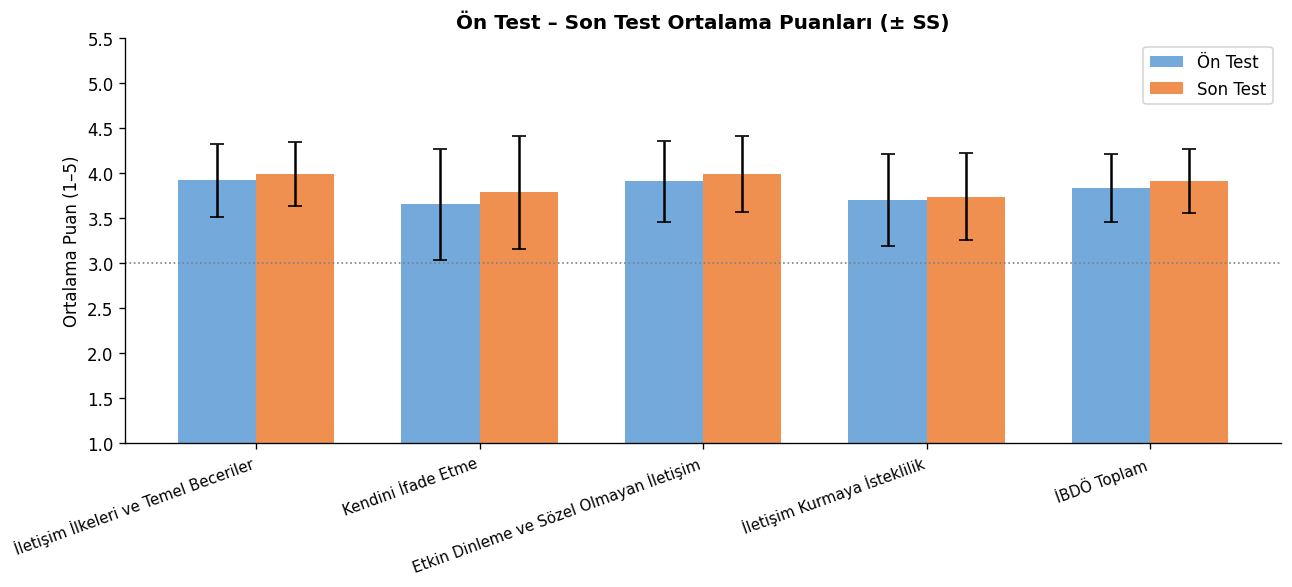

In [6]:
boyutlar = list(FAKTÖRLER.keys()) + ['Toplam']
etiketler = [FAKTÖR_ETIKET[b] for b in boyutlar]

on_ort  = [on[b].mean()  for b in boyutlar]
son_ort = [son[b].mean() for b in boyutlar]
on_ss   = [on[b].std(ddof=1)  for b in boyutlar]
son_ss  = [son[b].std(ddof=1) for b in boyutlar]

x = np.arange(len(etiketler))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, on_ort,  w, yerr=on_ss,  capsize=4, color=RENK_ON,  label='Ön Test',  alpha=0.85)
b2 = ax.bar(x + w/2, son_ort, w, yerr=son_ss, capsize=4, color=RENK_SON, label='Son Test', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(etiketler, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Ortalama Puan (1–5)')
ax.set_ylim(1, 5.5)
ax.set_title('Ön Test – Son Test Ortalama Puanları (± SS)', fontweight='bold')
ax.legend()
ax.axhline(3, color='gray', linestyle=':', linewidth=1)

plt.tight_layout()
plt.show()

## 4. Normallik Testi (Shapiro-Wilk)

In [7]:
norm = s['normallik']

def renk_normal(val):
    return 'color: green; font-weight: bold' if val == 'Evet' else 'color: red;'

display(norm.style
    .set_caption('Tablo: Shapiro-Wilk Normallik Testi Sonuçları')
    .applymap(renk_normal, subset=['Normal mi?'])
    .hide(axis='index')
)

Ölçek / Alt Boyut,Ölçüm,N,Shapiro-Wilk W,p,Normal mi?
İletişim İlkeleri ve Temel Beceriler,Ön Test,44,0.958000,0.107000,Evet
İletişim İlkeleri ve Temel Beceriler,Son Test,44,0.910000,0.002000,Hayır
Kendini İfade Etme,Ön Test,44,0.965000,0.201000,Evet
Kendini İfade Etme,Son Test,44,0.974000,0.400000,Evet
Etkin Dinleme ve Sözel Olmayan İletişim,Ön Test,44,0.974000,0.404000,Evet
Etkin Dinleme ve Sözel Olmayan İletişim,Son Test,44,0.951000,0.058000,Evet
İletişim Kurmaya İsteklilik,Ön Test,44,0.939000,0.022000,Hayır
İletişim Kurmaya İsteklilik,Son Test,44,0.958000,0.111000,Evet
İBDÖ Toplam,Ön Test,44,0.968000,0.267000,Evet
İBDÖ Toplam,Son Test,44,0.949000,0.051000,Evet


## 5. Bağımlı Örneklem t-Testi (Paired Samples t-Test)

In [8]:
tt = s['ttest']

def renk_anlamli(val):
    return 'color: green; font-weight: bold' if 'Evet' in str(val) else ''

display(tt.style
    .set_caption('Tablo: Bağımlı Örneklem t-Testi Sonuçları')
    .applymap(renk_anlamli, subset=['p < .05'])
    .hide(axis='index')
)

Ölçek / Alt Boyut,Ön x̄,Ön SS,Son x̄,Son SS,N,sd,t,p,p < .05,Cohen's d,Etki Büyüklüğü
İletişim İlkeleri ve Temel Beceriler,3.920000,0.403000,3.993000,0.359000,44,43,1.102000,0.277000,Hayır,0.166000,Çok küçük
Kendini İfade Etme,3.653000,0.613000,3.790000,0.629000,44,43,1.416000,0.164000,Hayır,0.213000,Küçük
Etkin Dinleme ve Sözel Olmayan İletişim,3.909000,0.454000,3.992000,0.419000,44,43,1.326000,0.192000,Hayır,0.200000,Çok küçük
İletişim Kurmaya İsteklilik,3.705000,0.513000,3.741000,0.479000,44,43,0.649000,0.520000,Hayır,0.098000,Çok küçük
İBDÖ Toplam,3.832000,0.379000,3.910000,0.357000,44,43,1.476000,0.147000,Hayır,0.223000,Küçük


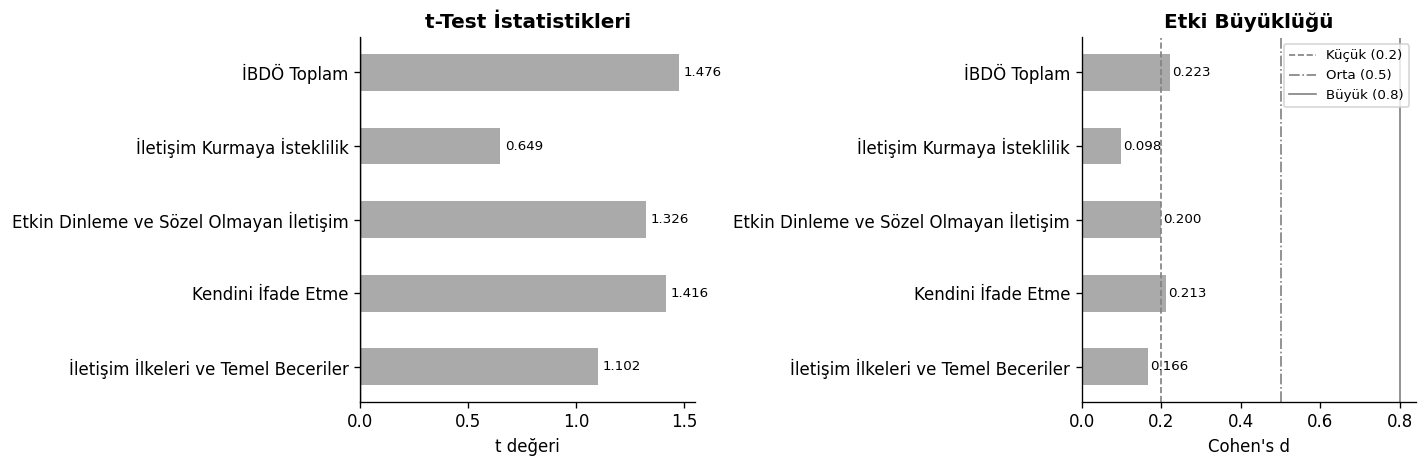

In [9]:
# t ve p değerlerini görselleştir
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

renkler_t = [RENK_SON if p < 0.05 else '#AAAAAA' for p in tt['p']]

# Sol: t değerleri
axes[0].barh(tt['Ölçek / Alt Boyut'], tt['t'], color=renkler_t, height=0.5)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('t değeri')
axes[0].set_title('t-Test İstatistikleri', fontweight='bold')

for i, (val, p) in enumerate(zip(tt['t'], tt['p'])):
    axes[0].text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=8)

# Sağ: Cohen's d
renkler_d = [RENK_SON if p < 0.05 else '#AAAAAA' for p in tt['p']]
axes[1].barh(tt['Ölçek / Alt Boyut'], tt["Cohen's d"], color=renkler_d, height=0.5)
axes[1].axvline(0.2, color='gray', linestyle='--', linewidth=1, label='Küçük (0.2)')
axes[1].axvline(0.5, color='gray', linestyle='-.',  linewidth=1, label='Orta (0.5)')
axes[1].axvline(0.8, color='gray', linestyle='-',   linewidth=1, label='Büyük (0.8)')
axes[1].set_xlabel("Cohen's d")
axes[1].set_title('Etki Büyüklüğü', fontweight='bold')
axes[1].legend(fontsize=8)

for i, val in enumerate(tt["Cohen's d"]):
    axes[1].text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

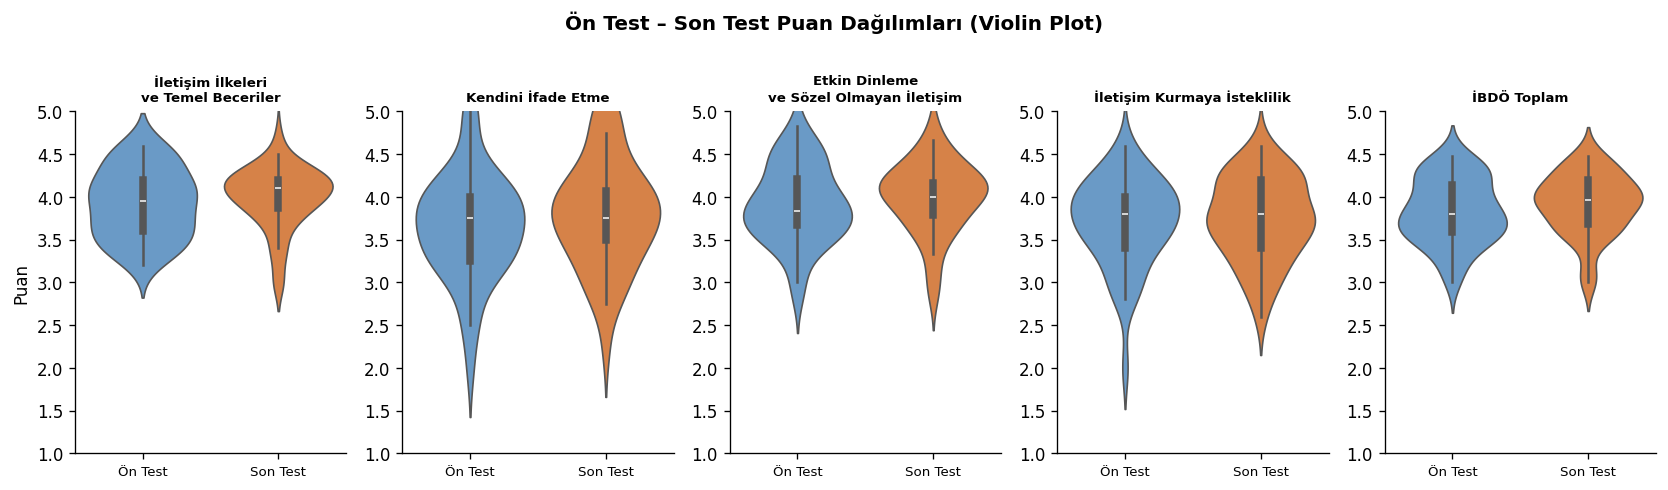

In [10]:
# Ön-Son Test dağılım karşılaştırması (violin + strip)
boyutlar_goster = list(FAKTÖRLER.keys()) + ['Toplam']
fig, axes = plt.subplots(1, len(boyutlar_goster), figsize=(14, 4), sharey=False)

for ax, b in zip(axes, boyutlar_goster):
    veri = pd.DataFrame({
        'Puan': list(on[b]) + list(son[b]),
        'Test': ['Ön Test'] * len(on) + ['Son Test'] * len(son),
    })
    sns.violinplot(data=veri, x='Test', y='Puan', palette=[RENK_ON, RENK_SON],
                   inner='box', ax=ax, linewidth=1)
    ax.set_title(FAKTÖR_ETIKET[b].replace(' ve ', '\nve '), fontsize=8, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylim(1, 5)
    ax.set_ylabel('Puan' if b == boyutlar_goster[0] else '')
    ax.tick_params(axis='x', labelsize=8)

fig.suptitle('Ön Test – Son Test Puan Dağılımları (Violin Plot)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Özet Yorum

Aşağıdaki hücre analiz sonuçlarına göre otomatik yorum üretir.

In [11]:
print('=' * 60)
print('İBDÖ ANALİZ ÖZET RAPORU')
print('=' * 60)
print(f"Eşleşen katılımcı sayısı (N): {s['n_eslesen']}")
print(f"Cronbach α (toplam)          : {s['guvenirlik'].iloc[-1]['Cronbach α']:.3f}")
print()

for _, row in s['ttest'].iterrows():
    anlamli = row['p'] < 0.05
    yon = 'artış' if row["Son x̄"] > row["Ön x̄"] else 'azalış'
    cohens_d = row["Cohen's d"]
    etki = row['Etki Büyüklüğü']
    sd_val = row['sd']
    t_val  = row['t']
    p_val  = row['p']
    print(f"[{'✓' if anlamli else '–'}] {row['Ölçek / Alt Boyut']}")
    print(f"    Ön: x̄={row['Ön x̄']:.3f}  Son: x̄={row['Son x̄']:.3f}  → {yon}")
    print(f"    t({sd_val})={t_val:.3f}, p={p_val:.3f}, d={cohens_d:.3f} ({etki})")
    durum = '✔ Anlamlı fark var (p < .05)' if anlamli else '✘ Anlamlı fark yok (p > .05)'
    print(f'    {durum}')
    print()


İBDÖ ANALİZ ÖZET RAPORU
Eşleşen katılımcı sayısı (N): 44
Cronbach α (toplam)          : 0.857

[–] İletişim İlkeleri ve Temel Beceriler
    Ön: x̄=3.920  Son: x̄=3.993  → artış
    t(43)=1.102, p=0.277, d=0.166 (Çok küçük)
    ✘ Anlamlı fark yok (p > .05)

[–] Kendini İfade Etme
    Ön: x̄=3.653  Son: x̄=3.790  → artış
    t(43)=1.416, p=0.164, d=0.213 (Küçük)
    ✘ Anlamlı fark yok (p > .05)

[–] Etkin Dinleme ve Sözel Olmayan İletişim
    Ön: x̄=3.909  Son: x̄=3.992  → artış
    t(43)=1.326, p=0.192, d=0.200 (Çok küçük)
    ✘ Anlamlı fark yok (p > .05)

[–] İletişim Kurmaya İsteklilik
    Ön: x̄=3.705  Son: x̄=3.741  → artış
    t(43)=0.649, p=0.520, d=0.098 (Çok küçük)
    ✘ Anlamlı fark yok (p > .05)

[–] İBDÖ Toplam
    Ön: x̄=3.832  Son: x̄=3.910  → artış
    t(43)=1.476, p=0.147, d=0.223 (Küçük)
    ✘ Anlamlı fark yok (p > .05)

